### 프로젝트 개요 및 회고
- 그동안 일화기억 기반 인지재활 프로젝트를 기획했었다.
- 즉 VQA로만 접근했는데 이번에 VQG라는 컨셉을 파악했다.
- 시간관계로 완성도는 높지 않지만, 몇달간 고민한 것의 단서를 찾았습니다. 감사합니다.
- 추후에 완성도를 높여 다시 제출하겠습니다.


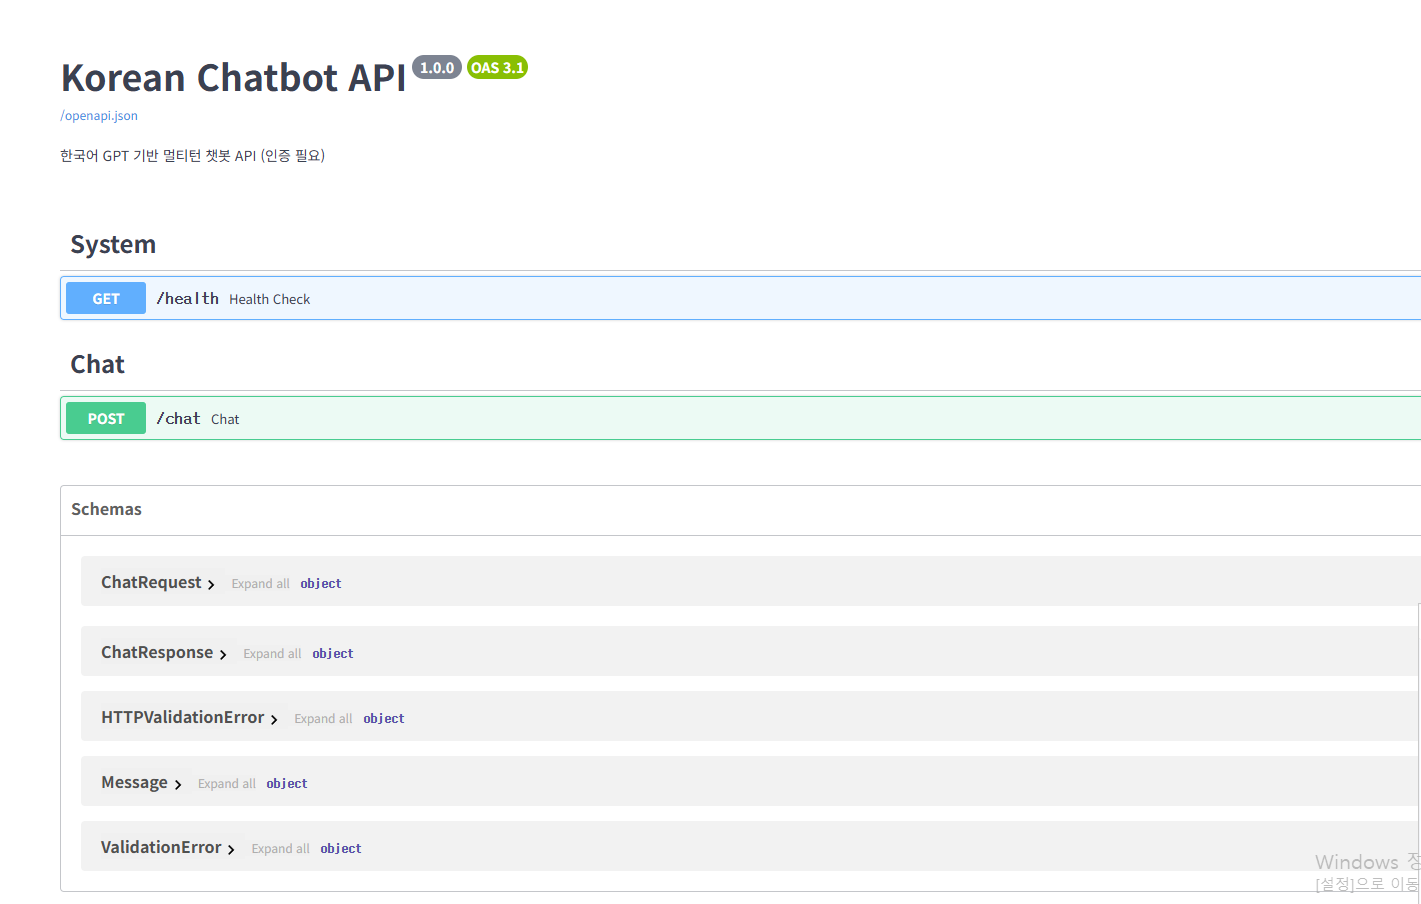

In [1]:
# ============================================================
# [STEP 0] 작업 폴더 설정
# ============================================================

import os

PROJECT_DIR = r"D:\PyProject\AIFFEL_AI\LLM\Deployment\Introduction\VQG"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

os.makedirs("app", exist_ok=True)
os.makedirs("frontend", exist_ok=True)

print("현재 작업 폴더:", os.getcwd())
print("app 폴더 존재:", os.path.exists("app"))
print("frontend 폴더 존재:", os.path.exists("frontend"))

현재 작업 폴더: D:\PyProject\AIFFEL_AI\LLM\Deployment\Introduction\VQG
app 폴더 존재: True
frontend 폴더 존재: True


In [3]:
# ============================================================
# [STEP 0-1] .env에서 HF_TOKEN 불러오기
# - D:\PyProject\env_keys\.env 에서 HF_TOKEN을 읽어옵니다.
# ============================================================

import os
from dotenv import load_dotenv

ENV_PATH = r"D:\PyProject\env_keys\.env"
load_dotenv(ENV_PATH)

hf_token = os.getenv("HF_TOKEN")

if hf_token:
    print("HF_TOKEN 로드 성공")
else:
    print("HF_TOKEN 로드 실패")

HF_TOKEN 로드 성공


In [5]:
# ============================================================
# [STEP 0-2] Hugging Face 로그인
# ============================================================

from huggingface_hub import login
import os

hf_token = os.getenv("HF_TOKEN")
login(token=hf_token)
print("Hugging Face 로그인 완료")

D:\anaconda3\envs\venv_conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Hugging Face 로그인 완료


In [7]:
# ============================================================
# [STEP 1] 모델 동작 확인
# - pipeline 형식 유지
# - 현재 transformers 버전에 맞게 image-text-to-text 사용
# - text 프롬프트를 함께 전달
# ============================================================

import os
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import pipeline
from PIL import Image

ENV_PATH = r"D:\PyProject\env_keys\.env"
load_dotenv(ENV_PATH)

hf_token = os.getenv("HF_TOKEN")
login(token=hf_token)

MODEL_NAME = "Salesforce/blip-image-captioning-base"
TEST_IMAGE_PATH = "test.png"   # 사과 3개 이미지

captioner = pipeline(
    task="image-text-to-text",
    model=MODEL_NAME,
    token=hf_token,
    use_safetensors=True,
    revision="refs/pr/51",
)

image = Image.open(TEST_IMAGE_PATH).convert("RGB")

# text를 반드시 같이 넣어야 함
result = captioner(images=image, text="a picture of")

print(result)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
Loading weights: 100%|█████████████████████████████████████████████████████████████| 472/472 [00:00<00:00, 7375.15it/s]
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Keyword argument `use_safetensors` is not a valid argument for this processor and will be ignored.
Passing `generation_config` together with generation-related arguments=({'eos_token_id', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[{'input_text': 'a picture of', 'generated_text': 'a picture of three apples on a plate'}]


In [8]:
%%writefile app/auth.py
"""
Day 6에서 만든 인증 모듈을 그대로 재사용함
"""
from fastapi import HTTPException, Header

VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:
    if x_api_key is None:
        raise HTTPException(
            status_code=401,
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )
    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )
    return VALID_API_KEYS[x_api_key]

Overwriting app/auth.py


In [9]:
%%writefile app/schemas.py
"""
입력/출력 스키마를 정의

프로젝트:
- 가족 사진 + 가족 캡션을 입력받아
- 인지재활용 질문(VQG)을 생성하는 서비스
"""

from pydantic import BaseModel, Field


class PredictRequest(BaseModel):
    image_base64: str = Field(
        ...,
        min_length=100,
        description="이미지를 base64로 인코딩한 문자열",
    )
    family_caption: str = Field(
        ...,
        min_length=1,
        max_length=300,
        description="가족이 적은 사진 설명/추억 캡션",
    )
    num_questions: int = Field(
        default=3,
        ge=1,
        le=5,
        description="생성할 질문 개수",
    )


class PredictResponse(BaseModel):
    success: bool
    scene_caption: str
    family_caption: str
    questions: list[str]

Overwriting app/schemas.py


In [10]:
%%writefile app/model_service.py
"""
모델 로드와 추론 함수를 정의합니다.
- pipeline 형식 유지
- image-text-to-text 사용
- text 프롬프트를 함께 넣어 캡션 생성
"""

import os
import base64
import io
import re
from PIL import Image
from dotenv import load_dotenv
from transformers import pipeline

ENV_PATH = r"D:\PyProject\env_keys\.env"
load_dotenv(ENV_PATH)

MODEL_NAME = "Salesforce/blip-image-captioning-base"


def load_model():
    model = pipeline(
        task="image-text-to-text",
        model=MODEL_NAME,
        token=os.getenv("HF_TOKEN"),
        use_safetensors=True,
        revision="refs/pr/51",
    )
    return model


def decode_base64_image(image_base64: str) -> Image.Image:
    if "," in image_base64:
        image_base64 = image_base64.split(",", 1)[1]

    image_bytes = base64.b64decode(image_base64)
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    return image


def clean_keyword(token: str) -> str:
    token = re.sub(r"(에서|으로|와|과|랑|은|는|이|가|을|를|의|도|에|께서|한테)$", "", token)
    return token.strip()


def extract_keywords(text: str) -> list[str]:
    tokens = re.findall(r"[가-힣A-Za-z0-9]+", text)

    stopwords = {
        "그리고", "함께", "우리", "가족", "사진", "모습", "이날", "그날",
        "있는", "찍은", "정말", "너무", "행복한", "즐거운", "추억", "장면"
    }

    keywords = []
    for token in tokens:
        token = clean_keyword(token)
        if len(token) < 2:
            continue
        if token in stopwords:
            continue
        if token not in keywords:
            keywords.append(token)

    return keywords[:5]


def build_questions(scene_caption: str, family_caption: str, num_questions: int = 3) -> list[str]:
    keywords = extract_keywords(family_caption)

    questions = []

    if len(keywords) >= 1:
        questions.append(f"이 사진을 보면 '{keywords[0]}'와(과) 관련해 어떤 기억이 떠오르시나요?")
    else:
        questions.append("이 사진을 보고 가장 먼저 떠오르는 기억은 무엇인가요?")

    if len(keywords) >= 2:
        questions.append(f"이날 '{keywords[1]}'와(과) 함께 무엇을 했는지 말씀해 보세요.")
    else:
        questions.append("이 사진 속에서 누구와 함께 있었는지 떠올려 보세요.")

    if len(keywords) >= 3:
        questions.append(f"이 사진이 찍힌 장소나 상황이 '{keywords[2]}'와 관련이 있나요?")
    else:
        questions.append("이 사진은 어디에서 찍은 것 같은지 기억나는 대로 말씀해 보세요.")

    questions.append("이날의 기분이나 분위기는 어땠는지 설명해 보세요.")
    questions.append("이 장면에서 있었던 일을 순서대로 짧게 말씀해 보세요.")
    questions.append(f"사진 장면 설명이 '{scene_caption}'인데, 이와 관련해 기억나는 경험이 있나요?")

    deduped = []
    for q in questions:
        if q not in deduped:
            deduped.append(q)

    return deduped[:num_questions]


def predict(model, image_base64: str, family_caption: str, num_questions: int = 3) -> dict:
    image = decode_base64_image(image_base64)

    # image-text-to-text 파이프라인은 text를 같이 넣어야 함
    result = model(images=image, text="a picture of")
    scene_caption = result[0]["generated_text"].strip()

    questions = build_questions(
        scene_caption=scene_caption,
        family_caption=family_caption,
        num_questions=num_questions,
    )

    return {
        "success": True,
        "scene_caption": scene_caption,
        "family_caption": family_caption,
        "questions": questions,
    }

Overwriting app/model_service.py


In [15]:
%%writefile app/main.py
"""
FastAPI 서버를 정의합니다.

기능:
1. FastAPI 앱 생성
2. startup 이벤트에서 모델 로드
3. GET /            -> 간단한 웹 화면
4. GET /health
5. POST /predict    -> JSON API
6. POST /predict-form -> HTML form 업로드 처리
"""

import asyncio
import base64
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, Depends, HTTPException, UploadFile, File, Form
from fastapi.responses import HTMLResponse
from app.auth import verify_api_key
from app.schemas import PredictRequest, PredictResponse
from app.model_service import load_model, predict


app = FastAPI(title="Episodic Memory VQG API")

executor = ThreadPoolExecutor(max_workers=2)
model = None


@app.on_event("startup")
async def startup_event():
    global model
    model = load_model()


@app.get("/", response_class=HTMLResponse)
async def home():
    return """
    <html>
    <head>
        <meta charset="utf-8">
        <title>Episodic Memory VQG</title>
        <style>
            body {
                font-family: Arial, sans-serif;
                max-width: 760px;
                margin: 40px auto;
                padding: 20px;
                line-height: 1.6;
            }
            h1 { margin-bottom: 8px; }
            .box {
                border: 1px solid #ddd;
                border-radius: 12px;
                padding: 20px;
                margin-top: 20px;
            }
            input, textarea, button {
                width: 100%;
                padding: 10px;
                margin-top: 8px;
                margin-bottom: 16px;
                box-sizing: border-box;
            }
            button {
                cursor: pointer;
                font-size: 16px;
            }
            .muted {
                color: #666;
                font-size: 14px;
            }
        </style>
    </head>
    <body>
        <h1>🧠 일화기억 기반 인지재활 VQG</h1>
        <p class="muted">가족 사진과 가족 캡션을 입력하면 회상 질문을 생성합니다.</p>

        <div class="box">
            <form action="/predict-form" method="post" enctype="multipart/form-data">
                <label>API Key</label>
                <input type="text" name="api_key" value="test-key-001" />

                <label>가족 사진 업로드</label>
                <input type="file" name="image_file" accept=".jpg,.jpeg,.png" required />

                <label>가족 캡션</label>
                <textarea name="family_caption" rows="4" placeholder="예: 2024년 봄, 민수와 한강에서 놀던 날" required></textarea>

                <label>질문 개수 (1~5)</label>
                <input type="number" name="num_questions" min="1" max="5" value="3" />

                <button type="submit">질문 생성하기</button>
            </form>
        </div>

        <div class="box">
            <p><b>API 문서:</b> <a href="/docs" target="_blank">/docs</a></p>
            <p><b>상태 확인:</b> <a href="/health" target="_blank">/health</a></p>
        </div>
    </body>
    </html>
    """


@app.get("/health")
async def health():
    return {
        "status": "ok",
        "model_loaded": model is not None,
    }


@app.post("/predict", response_model=PredictResponse)
async def predict_endpoint(
    request: PredictRequest,
    user: str = Depends(verify_api_key),
):
    global model

    if model is None:
        raise HTTPException(status_code=500, detail="모델이 아직 로드되지 않았습니다.")

    loop = asyncio.get_running_loop()

    try:
        result = await loop.run_in_executor(
            executor,
            lambda: predict(
                model=model,
                image_base64=request.image_base64,
                family_caption=request.family_caption,
                num_questions=request.num_questions,
            ),
        )
        return result

    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 중 오류 발생: {str(e)}")


@app.post("/predict-form", response_class=HTMLResponse)
async def predict_form(
    api_key: str = Form(...),
    image_file: UploadFile = File(...),
    family_caption: str = Form(...),
    num_questions: int = Form(3),
):
    global model

    if api_key not in {"test-key-001", "test-key-002"}:
        return """
        <html><body>
        <h3>인증 실패</h3>
        <p>유효하지 않은 API Key입니다.</p>
        <a href="/">돌아가기</a>
        </body></html>
        """

    if model is None:
        return """
        <html><body>
        <h3>오류</h3>
        <p>모델이 아직 로드되지 않았습니다.</p>
        <a href="/">돌아가기</a>
        </body></html>
        """

    try:
        image_bytes = await image_file.read()
        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(
            executor,
            lambda: predict(
                model=model,
                image_base64=image_base64,
                family_caption=family_caption,
                num_questions=num_questions,
            ),
        )

        questions_html = "".join([f"<li>{q}</li>" for q in result["questions"]])

        return f"""
        <html>
        <head>
            <meta charset="utf-8">
            <title>VQG 결과</title>
            <style>
                body {{
                    font-family: Arial, sans-serif;
                    max-width: 760px;
                    margin: 40px auto;
                    padding: 20px;
                    line-height: 1.6;
                }}
                .box {{
                    border: 1px solid #ddd;
                    border-radius: 12px;
                    padding: 20px;
                    margin-top: 20px;
                }}
            </style>
        </head>
        <body>
            <h1>🧠 생성 결과</h1>

            <div class="box">
                <h3>장면 설명</h3>
                <p>{result["scene_caption"]}</p>
            </div>

            <div class="box">
                <h3>가족 캡션</h3>
                <p>{result["family_caption"]}</p>
            </div>

            <div class="box">
                <h3>생성된 인지재활 질문</h3>
                <ol>
                    {questions_html}
                </ol>
            </div>

            <p><a href="/">다시 입력하기</a></p>
        </body>
        </html>
        """

    except Exception as e:
        return f"""
        <html><body>
        <h3>오류 발생</h3>
        <p>{str(e)}</p>
        <a href="/">돌아가기</a>
        </body></html>
        """

Overwriting app/main.py


In [17]:
%%writefile frontend/app.py
"""
Streamlit 프론트엔드를 정의합니다.

기능:
1. 제목 표시
2. 사이드바 API Key 입력
3. 이미지 업로드 + 가족 캡션 입력
4. 버튼 클릭 시 API 호출
5. 결과 표시
"""

import base64
import requests
import streamlit as st

API_URL = "http://localhost:8000/predict"

st.set_page_config(page_title="인지재활 VQG 데모", layout="centered")

st.title("🧠 일화기억 기반 인지재활 VQG 데모")
st.write("가족 사진과 가족 캡션을 바탕으로 회상 질문을 생성합니다.")

st.sidebar.header("API 설정")
api_key = st.sidebar.text_input("API Key", value="test-key-001", type="password")

uploaded_file = st.file_uploader("가족 사진 업로드", type=["jpg", "jpeg", "png"])
family_caption = st.text_area(
    "가족 캡션 입력",
    placeholder="예: 2024년 봄, 민수와 한강에서 놀던 날",
)
num_questions = st.slider("질문 개수", min_value=1, max_value=5, value=3)

if uploaded_file is not None:
    st.image(uploaded_file, caption="업로드한 이미지", use_container_width=True)

if st.button("질문 생성하기"):
    if uploaded_file is None:
        st.error("이미지를 업로드해 주세요.")
    elif not family_caption.strip():
        st.error("가족 캡션을 입력해 주세요.")
    else:
        image_bytes = uploaded_file.read()
        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        payload = {
            "image_base64": image_base64,
            "family_caption": family_caption,
            "num_questions": num_questions,
        }

        headers = {
            "X-API-Key": api_key,
        }

        try:
            response = requests.post(API_URL, json=payload, headers=headers, timeout=120)

            if response.status_code == 200:
                data = response.json()

                st.success("질문 생성 완료")

                st.subheader("장면 설명")
                st.write(data["scene_caption"])

                st.subheader("가족 캡션")
                st.write(data["family_caption"])

                st.subheader("생성된 인지재활 질문")
                for i, q in enumerate(data["questions"], start=1):
                    st.write(f"{i}. {q}")
            else:
                st.error(f"API 오류 ({response.status_code})")
                st.code(response.text)

        except Exception as e:
            st.error(f"요청 실패: {e}")

Overwriting frontend/app.py


In [19]:
# ⚠️ 커널 재시작 후 실행하세요

import nest_asyncio, uvicorn, threading, time
nest_asyncio.apply()

def run_server():
    uvicorn.run("app.main:app", host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(3)

print("✅ 서버 시작됨")
print("메인 화면: http://localhost:8000/")
print("API 문서:  http://localhost:8000/docs")

INFO:     Started server process [31380]
INFO:     Waiting for application startup.
Loading weights: 100%|█████████████████████████████████████████████████████████████| 472/472 [00:00<00:00, 8000.00it/s]
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 서버 시작됨
메인 화면: http://localhost:8000/
API 문서:  http://localhost:8000/docs


In [21]:
import base64
import requests

API_URL = "http://localhost:8000"
HEADERS = {"X-API-Key": "test-key-001"}

# health check
print(requests.get(f"{API_URL}/health").json())

# 테스트 이미지 파일
image_path = "test.png"

with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")

response = requests.post(
    f"{API_URL}/predict",
    json={
        "image_base64": image_base64,
        "family_caption": "2024년 봄, 민수와 한강에서 놀던 날 먹었던 과일",
        "num_questions": 3
    },
    headers=HEADERS,
)

print(f"상태: {response.status_code}")
print(f"결과: {response.json()}")

{'status': 'healthy', 'model': 'skt/kogpt2-base-v2'}
상태: 404
결과: {'detail': 'Not Found'}
